# Hockey Career Trajectory Predictor — Evaluation

Analysis of the walk-forward backtest outputs (1990-91 → 2025-26).
Run `python -m src.backtest` first to produce `data/output/*`.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

OUT = Path('../data/output')
vet_preds = pd.read_parquet(OUT / 'veteran_predictions.parquet')
vet_seasons = pd.read_csv(OUT / 'veteran_season_metrics.csv')
rook_preds = pd.read_parquet(OUT / 'rookie_predictions.parquet')
rook_classes = pd.read_csv(OUT / 'rookie_class_metrics.csv')
veterans = pd.read_parquet(OUT / 'veteran_features.parquet')
rookies = pd.read_parquet(OUT / 'rookie_features.parquet')
plt.rcParams['figure.figsize'] = (11, 4)

## 1. Veteran model: accuracy over time

Success metric (PRD): **MAE < 0.08 PPG** league-wide, and beating the 'last season's PPG' baseline.

Seasons evaluated : 35
Mean MAE (model)  : 0.1285
Mean MAE (baseline): 0.1538
Mean R2           : 0.632
Directional acc.  : 68.3%


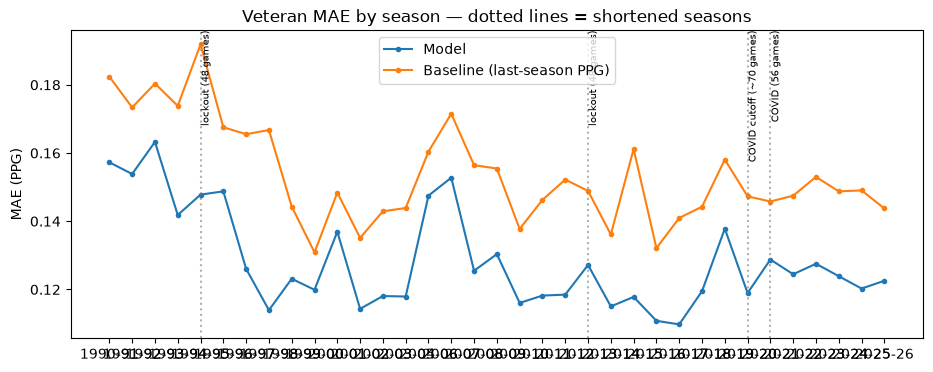

In [2]:
m = vet_seasons.dropna(subset=['mae'])
print(f"Seasons evaluated : {len(m)}")
print(f"Mean MAE (model)  : {m['mae'].mean():.4f}")
print(f"Mean MAE (baseline): {m['mae_baseline'].mean():.4f}")
print(f"Mean R2           : {m['r2'].mean():.3f}")
print(f"Directional acc.  : {m['directional_accuracy'].mean():.1%}")

fig, ax = plt.subplots()
ax.plot(m['season'], m['mae'], marker='o', ms=3, label='Model')
ax.plot(m['season'], m['mae_baseline'], marker='o', ms=3, label='Baseline (last-season PPG)')
for _, r in m[m['shortened'].fillna('') != ''].iterrows():
    ax.axvline(r['season'], ls=':', color='gray', alpha=.6)
    ax.annotate(r['shortened'], (r['season'], ax.get_ylim()[1]), rotation=90, fontsize=7, va='top')
ax.set_ylabel('MAE (PPG)'); ax.legend(); ax.set_title('Veteran MAE by season — dotted lines = shortened seasons')
plt.show()

In [3]:
# Biggest over/under-performers across the whole backtest
ev = vet_preds[vet_preds['eval_ok']].dropna(subset=['ppg_next']).copy()
ev['err'] = ev['ppg_next'] - ev['pred_ppg']
from src.constants import season_label
ev['season'] = ev['pred_season'].map(season_label)
cols = ['skaterFullName', 'season', 'ppg_last1', 'pred_ppg', 'ppg_next', 'err']
display(ev.nlargest(10, 'err')[cols])
display(ev.nsmallest(10, 'err')[cols])

,skaterFullName,season,ppg_last1,pred_ppg,ppg_next,err
420,Mark Recchi,1990-91,0.133333,0.291228,1.448718,1.157490
382,Adam Oates,1990-91,1.130435,0.792291,1.885246,1.092955
1411,Mario Lemieux,1992-93,1.730769,1.732434,2.666667,0.934233
22486,Tage Thompson,2022-23,0.368421,0.293736,1.205128,0.911393
12060,Mike Green,2008-09,0.171429,0.210722,1.073529,0.862808
9800,Jonathan Cheechoo,2005-06,0.242424,0.286833,1.134146,0.847313
9967,Jason Spezza,2005-06,0.636364,0.514478,1.323529,0.809051
3504,Ziggy Palffy,1995-96,0.000000,0.279771,1.074074,0.794303
21962,Erik Karlsson,2022-23,0.423077,0.449831,1.231707,0.781877
21787,Jason Robertson,2021-22,0.333333,0.286967,1.067568,0.780600


,skaterFullName,season,ppg_last1,pred_ppg,ppg_next,err
4223,Curtis Brown,1996-97,2.000000,1.027186,0.250000,-0.777186
2055,Eddie Olczyk,1993-94,1.015625,0.918508,0.216216,-0.702292
14073,Mike Green,2011-12,1.013333,0.873677,0.218750,-0.654927
58,Jimmy Carson,1990-91,1.250000,1.366315,0.718750,-0.647565
39,Rob Brown,1990-91,1.691176,1.459120,0.840580,-0.618540
20453,Evgenii Dadonov,2020-21,0.853659,0.968416,0.363636,-0.604780
2879,Dixon Ward,1994-95,0.742857,0.726558,0.136364,-0.590194
159,Gerard Gallant,1990-91,1.223684,1.162306,0.577778,-0.584528
2772,Steve Yzerman,1994-95,1.630952,1.367922,0.808511,-0.559411
449,Denis Savard,1990-91,1.413793,1.388889,0.842857,-0.546032


## 1b. Availability sensitivity — would excluding injured players help?

Hindsight analysis (not deployable: you can't know in October who gets hurt in February). Tests whether MAE improves when filtering out players with reduced availability in the target season.

In [4]:
from sklearn.metrics import mean_absolute_error

feats = veterans[['playerId', 'seasonId', 'gp_last1']]
ev2 = ev.merge(feats, on=['playerId', 'seasonId'])
ev2['gp_ratio'] = ev2['gp_next'] / ev2['gp_last1']

def mae_of(df):
    return mean_absolute_error(df['ppg_next'], df['pred_ppg'])

print(f'all eval players (>=15 GP)      : n={len(ev2):5d}  MAE={mae_of(ev2):.4f}')
for thr in [30, 41, 60, 70]:
    sub = ev2[ev2['gp_next'] >= thr]
    print(f'played >= {thr:2d} GP next season  : n={len(sub):5d}  MAE={mae_of(sub):.4f}')
collapsed = ev2[ev2['gp_ratio'] < 0.6]
healthy = ev2[ev2['gp_ratio'] >= 0.6]
print(f'GP collapsed (<60% of prior yr): n={len(collapsed):5d}  MAE={mae_of(collapsed):.4f}  '
      f'(mean err {collapsed["err"].mean():+.3f} -> model overpredicts the hurt)')
print(f'no collapse                    : n={len(healthy):5d}  MAE={mae_of(healthy):.4f}')
print()
print('Takeaway: injuries cost ~0.010 MAE on the affected players, but excluding them')
print('moves the headline number by only ~0.001, and harsher GP thresholds HURT — they')
print('remove easy-to-predict depth players and leave only volatile stars.')

all eval players (>=15 GP)      : n=18653  MAE=0.1275
played >= 30 GP next season  : n=17171  MAE=0.1270
played >= 41 GP next season  : n=15829  MAE=0.1277
played >= 60 GP next season  : n=11901  MAE=0.1304
played >= 70 GP next season  : n= 8861  MAE=0.1345
GP collapsed (<60% of prior yr): n= 2049  MAE=0.1366  (mean err -0.058 -> model overpredicts the hurt)
no collapse                    : n=16604  MAE=0.1263

Takeaway: injuries cost ~0.010 MAE on the affected players, but excluding them
moves the headline number by only ~0.001, and harsher GP thresholds HURT — they
remove easy-to-predict depth players and leave only volatile stars.


## 1c. Most accurate predictions, biggest busts, biggest risers

In [5]:
cols = ['skaterFullName', 'season', 'ppg_last1', 'pred_ppg', 'ppg_next', 'err']
ev2['abs_err'] = ev2['err'].abs()
print('Most accurate (boring is predictable — stable mid-tier veterans):')
display(ev2.nsmallest(10, 'abs_err')[cols])
print('Biggest busts (predicted high, delivered low):')
display(ev2.nsmallest(10, 'err')[cols])
print('Biggest risers (delivered far above prediction — the honest ceiling of box-score models):')
display(ev2.nlargest(10, 'err')[cols])

Most accurate (boring is predictable — stable mid-tier veterans):


,skaterFullName,season,ppg_last1,pred_ppg,ppg_next,err
14831,Tyler Pitlick,2019-20,0.337500,0.317449,0.317460,0.000011
11087,Niklas Hjalmarsson,2012-13,0.125000,0.217372,0.217391,0.000019
785,Darren Turcotte,1991-92,0.868421,0.746502,0.746479,-0.000023
11797,Justin Faulk,2013-14,0.333333,0.421027,0.421053,0.000026
10775,Marian Hossa,2012-13,0.876923,0.774942,0.775000,0.000058
2195,Yuri Khmylev,1994-95,0.573529,0.520896,0.520833,-0.000063
16472,Mark Jankowski,2022-23,0.244444,0.239937,0.240000,0.000063
9305,John-Michael Liles,2009-10,0.395062,0.525358,0.525424,0.000065
11382,Marcel Goc,2013-14,0.473684,0.337904,0.337838,-0.000066
6016,Roman Hamrlik,2002-03,0.605263,0.561542,0.561644,0.000102


Biggest busts (predicted high, delivered low):


,skaterFullName,season,ppg_last1,pred_ppg,ppg_next,err
3170,Curtis Brown,1996-97,2.000000,1.027186,0.250000,-0.777186
1539,Eddie Olczyk,1993-94,1.015625,0.918508,0.216216,-0.702292
10518,Mike Green,2011-12,1.013333,0.873677,0.218750,-0.654927
45,Jimmy Carson,1990-91,1.250000,1.366315,0.718750,-0.647565
28,Rob Brown,1990-91,1.691176,1.459120,0.840580,-0.618540
15241,Evgenii Dadonov,2020-21,0.853659,0.968416,0.363636,-0.604780
2158,Dixon Ward,1994-95,0.742857,0.726558,0.136364,-0.590194
118,Gerard Gallant,1990-91,1.223684,1.162306,0.577778,-0.584528
2088,Steve Yzerman,1994-95,1.630952,1.367922,0.808511,-0.559411
319,Denis Savard,1990-91,1.413793,1.388889,0.842857,-0.546032


Biggest risers (delivered far above prediction — the honest ceiling of box-score models):


,skaterFullName,season,ppg_last1,pred_ppg,ppg_next,err
298,Mark Recchi,1990-91,0.133333,0.291228,1.448718,1.157490
273,Adam Oates,1990-91,1.130435,0.792291,1.885246,1.092955
1052,Mario Lemieux,1992-93,1.730769,1.732434,2.666667,0.934233
16722,Tage Thompson,2022-23,0.368421,0.293736,1.205128,0.911393
8999,Mike Green,2008-09,0.171429,0.210722,1.073529,0.862808
7339,Jonathan Cheechoo,2005-06,0.242424,0.286833,1.134146,0.847313
7448,Jason Spezza,2005-06,0.636364,0.514478,1.323529,0.809051
2630,Ziggy Palffy,1995-96,0.000000,0.279771,1.074074,0.794303
16333,Erik Karlsson,2022-23,0.423077,0.449831,1.231707,0.781877
16224,Jason Robertson,2021-22,0.333333,0.286967,1.067568,0.780600


## 2. Rookie model: draft-class walk-forward

Success metric (PRD): **Spearman ρ > 0.55** between predicted and actual rookie PPG.
Pre-NHL production is NHLe-translated from NHL bio seasonTotals (53k stints).

Classes evaluated : 35
Mean MAE          : 0.1189
Mean Spearman rho : 0.503


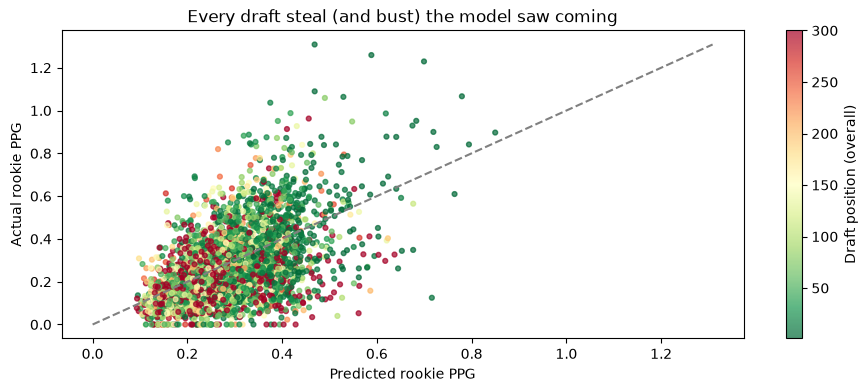

In [6]:
print(f"Classes evaluated : {len(rook_classes)}")
print(f"Mean MAE          : {rook_classes['mae'].mean():.4f}")
print(f"Mean Spearman rho : {rook_classes['spearman'].mean():.3f}")

fig, ax = plt.subplots()
sc = ax.scatter(rook_preds['pred_ppg'], rook_preds['ppg_rookie'],
                c=rook_preds['draft_ovr'], cmap='RdYlGn_r', s=12, alpha=.7)
lim = max(rook_preds['pred_ppg'].max(), rook_preds['ppg_rookie'].max())
ax.plot([0, lim], [0, lim], ls='--', color='gray')
plt.colorbar(sc, label='Draft position (overall)')
ax.set_xlabel('Predicted rookie PPG'); ax.set_ylabel('Actual rookie PPG')
ax.set_title('Every draft steal (and bust) the model saw coming')
plt.show()

In [7]:
# Steals: predicted well above draft-slot expectation AND delivered
rp = rook_preds.copy()
rp['draft_decile'] = pd.qcut(rp['draft_ovr'], 10, labels=False, duplicates='drop')
rp['expectation'] = rp.groupby('draft_decile')['ppg_rookie'].transform('mean')  # empirical draft-slot expectation
rp['steal_score'] = rp['pred_ppg'] - rp['expectation']
rp['delivered'] = rp['ppg_rookie'] - rp['expectation']
rp['season'] = rp['rookie_season'].map(season_label)
cols = ['skaterFullName', 'season', 'draft_ovr', 'pred_ppg', 'ppg_rookie', 'steal_score']
print('Top steals (model high, draft low, player delivered):')
display(rp[rp['delivered'] > 0].nlargest(15, 'steal_score')[cols])
print('Top busts (top-10 pick, lowest actual):')
display(rp[rp['draft_ovr'] <= 10].nsmallest(15, 'ppg_rookie')[cols])

Top steals (model high, draft low, player delivered):


,skaterFullName,season,draft_ovr,pred_ppg,ppg_rookie,steal_score
3020,Connor Bedard,2023-24,1.0,0.849762,0.897059,0.446423
329,Miroslav Satan,1995-96,111.0,0.676674,0.564516,0.434362
546,Brad Smyth,1996-97,300.0,0.637272,0.326923,0.392213
2445,Auston Matthews,2016-17,1.0,0.794318,0.841463,0.390979
2336,Connor McDavid,2015-16,1.0,0.779432,1.066667,0.376093
12,Michael McNeil,1990-91,300.0,0.617653,0.297297,0.372594
2988,Juraj Slafkovský,2023-24,1.0,0.763968,0.609756,0.360630
604,Kai Nurminen,1996-97,193.0,0.623270,0.402985,0.358487
179,C.J. Young,1992-93,300.0,0.603447,0.325581,0.358388
600,Andreas Dackell,1996-97,136.0,0.620795,0.392405,0.353873


Top busts (top-10 pick, lowest actual):


,skaterFullName,season,draft_ovr,pred_ppg,ppg_rookie,steal_score
1280,Alexandre Picard,2005-06,8.0,0.339482,0.000000,-0.063857
1618,Keaton Ellerby,2009-10,10.0,0.220348,0.000000,-0.182990
1892,Nino Niederreiter,2011-12,5.0,0.335143,0.018182,-0.068196
557,Johnathan Aitken,2003-04,8.0,0.121967,0.024390,-0.281371
96,Alek Stojanov,1995-96,7.0,0.276300,0.029412,-0.127038
558,Ruslan Salei,1996-97,9.0,0.302753,0.033333,-0.100586
2039,Griffin Reinhart,2015-16,4.0,0.215013,0.034483,-0.188326
3046,Dmitri Simashev,2025-26,6.0,0.195016,0.035714,-0.208323
1003,Mike Komisarek,2002-03,7.0,0.248533,0.047619,-0.154805
721,Rico Fata,1998-99,6.0,0.273973,0.050000,-0.129365


## 1d. Tail predictions: breakouts and slumps (quantile models)

Alongside the mean model, q10/q50/q90 pinball-loss models are trained each
season (`python -m src.backtest --quantiles`). The **upside spread**
(q90−q50) is the model's breakout-risk score; the **downside spread**
(q50−q10) is its slump-risk score. A breakout is actual − last-season PPG
≥ +0.30; a slump ≤ −0.30.

In [8]:
from src.tails import evaluate_tails
evq = evaluate_tails()

evaluated player-seasons : 18653
80% interval coverage    : 0.797 (target 0.80)
breakouts (>= +0.3 PPG) : 1260  upside AUC = 0.631
slumps    (<= -0.3 PPG) : 1192  downside AUC = 0.691

precision@50 breakouts: 0.126 (base rate 0.068)
precision@50 slumps   : 0.147 (base rate 0.065)

Highest-upside calls that delivered (top 10 by upside among actual breakouts):
    skaterFullName  season  ppg_last1  pred_ppg_q50  pred_ppg_q90  ppg_next    delta
     Mario Lemieux 1992-93   1.730769      1.361844      2.062055  2.666667 0.935897
    Milan Michalek 2006-07   0.500000      0.268255      0.848645  0.846154 0.346154
     Teemu Selanne 1995-96   1.058824      0.863810      1.394301  1.367089 0.308265
   Darren Turcotte 1990-91   0.500000      0.333873      0.859380  0.905405 0.405405
     Keith Tkachuk 1993-94   0.470588      0.389731      0.903777  0.964286 0.493697
Sergei Krivokrasov 1994-95   0.000000      0.307029      0.817386  0.463415 0.463415
    Robert Reichel 1992-93   0.621212      0

In [9]:
# Where do the greats land in their own prediction intervals?
cols = ['season', 'ppg_last1', 'pred_ppg_q10', 'pred_ppg_q50', 'pred_ppg_q90', 'ppg_next']
for name in ['Connor McDavid', 'Auston Matthews', 'Mario Lemieux']:
    sub = evq[evq['skaterFullName'] == name]
    if len(sub):
        print(f'--- {name} ---')
        display(sub[cols].round(3))

--- Connor McDavid ---


,season,ppg_last1,pred_ppg_q10,pred_ppg_q50,pred_ppg_q90,ppg_next
18792,2017-18,1.067,0.489,0.769,1.048,1.317
19514,2018-19,1.220,0.799,0.941,1.164,1.487
20224,2019-20,1.317,0.783,1.032,1.248,1.516
20919,2020-21,1.487,0.709,1.119,1.394,1.875
21613,2021-22,1.516,0.690,1.140,1.471,1.538
22347,2022-23,1.875,0.909,1.147,1.498,1.866
23096,2023-24,1.538,1.020,1.347,1.505,1.737
23872,2024-25,1.866,0.793,1.391,1.641,1.493
24611,2025-26,1.737,0.915,1.283,1.703,1.683


--- Auston Matthews ---


,season,ppg_last1,pred_ppg_q10,pred_ppg_q50,pred_ppg_q90,ppg_next
19555,2018-19,0.841,0.615,0.759,1.043,1.074
20285,2019-20,1.016,0.671,0.921,1.185,1.143
20993,2020-21,1.074,0.642,1.045,1.349,1.269
21700,2021-22,1.143,0.684,1.125,1.431,1.452
22441,2022-23,1.269,0.908,1.112,1.561,1.149
23178,2023-24,1.452,0.962,1.332,1.465,1.321
23944,2024-25,1.149,0.788,1.273,1.475,1.164
24683,2025-26,1.321,0.960,1.185,1.504,0.883


--- Mario Lemieux ---


,season,ppg_last1,pred_ppg_q10,pred_ppg_q50,pred_ppg_q90,ppg_next
281,1990-91,2.618,0.815,1.304,2.117,1.731
836,1991-92,2.085,0.860,1.304,2.211,2.047
1411,1992-93,1.731,0.746,1.362,2.062,2.667
1967,1993-94,2.047,0.948,1.556,1.987,1.682
3772,1996-97,1.682,0.684,1.157,1.576,1.605
7047,2001-02,1.605,0.717,1.136,1.474,1.292
7770,2002-03,1.767,0.651,0.937,1.254,1.358
9261,2005-06,1.358,0.618,0.817,1.277,0.846


## 1e. Archetype predictability ranking

Position × age band × production tier (last-season PPG), ranked by MAE.

In [10]:
import numpy as np
feats2 = veterans[['playerId', 'seasonId', 'age', 'is_defense']]
eva = ev.merge(feats2, on=['playerId', 'seasonId'])
eva['abs_err'] = (eva['ppg_next'] - eva['pred_ppg']).abs()
eva['pos'] = np.where(eva['is_defense'] == 1, 'D', 'F')
eva['age_band'] = pd.cut(eva['age'], [0, 22, 26, 30, 50],
                         labels=['<=22 (developing)', '23-26 (pre-peak)', '27-30 (post-peak)', '31+ (declining)'])
eva['tier'] = pd.cut(eva['ppg_last1'], [-1, 0.25, 0.55, 0.85, 10],
                     labels=['depth (<0.25)', 'middle (0.25-0.55)', 'top (0.55-0.85)', 'elite (>0.85)'])
eva['archetype'] = eva['pos'] + ' | ' + eva['age_band'].astype(str) + ' | ' + eva['tier'].astype(str)
rank = (eva.groupby('archetype', observed=True)
        .agg(n=('abs_err', 'size'), mae=('abs_err', 'mean'),
             bias=('ppg_next', 'size'))  # placeholder, replaced below
        .drop(columns='bias'))
rank['bias(+ = underpredicted)'] = eva.groupby('archetype', observed=True).apply(
    lambda d: (d['ppg_next'] - d['pred_ppg']).mean(), include_groups=False)
display(rank[rank['n'] >= 100].sort_values('mae').round(3))
print('Small-sample cells (n < 100):')
display(rank[rank['n'] < 100].sort_values('mae').round(3))
print()
print('Laws: (1) D easier than F at every age/tier; (2) low production easy, elite hard —')
print('error scales with the mean; (3) young+good is hardest and always UNDER-predicted')
print('(mean reversion cannot see the development curve arriving).')

,n,mae,bias(+ = underpredicted)
archetype,,,
D | 31+ (declining) | depth (<0.25),739,0.061,-0.003
F | 31+ (declining) | depth (<0.25),476,0.074,-0.013
D | 27-30 (post-peak) | depth (<0.25),997,0.077,0.004
D | 23-26 (pre-peak) | depth (<0.25),1144,0.086,-0.002
F | 27-30 (post-peak) | depth (<0.25),876,0.092,0.013
D | 31+ (declining) | middle (0.25-0.55),689,0.097,0.010
D | 27-30 (post-peak) | middle (0.25-0.55),843,0.107,0.014
F | 31+ (declining) | middle (0.25-0.55),990,0.113,0.001
D | <=22 (developing) | depth (<0.25),244,0.118,-0.006


Small-sample cells (n < 100):


,n,mae,bias(+ = underpredicted)
archetype,,,
D | 23-26 (pre-peak) | elite (>0.85),40,0.149,-0.007
D | 31+ (declining) | elite (>0.85),52,0.153,0.030
D | <=22 (developing) | top (0.55-0.85),23,0.154,-0.081
D | 27-30 (post-peak) | elite (>0.85),50,0.155,0.028
D | <=22 (developing) | elite (>0.85),10,0.206,0.017
F | <=22 (developing) | elite (>0.85),96,0.242,0.047



Laws: (1) D easier than F at every age/tier; (2) low production easy, elite hard —
error scales with the mean; (3) young+good is hardest and always UNDER-predicted
(mean reversion cannot see the development curve arriving).


## 3. Interpretability: SHAP on the final veteran model

PRD narrative hook: *the aging curve is real* — `age`/`age_sq` should rank among the most important features.

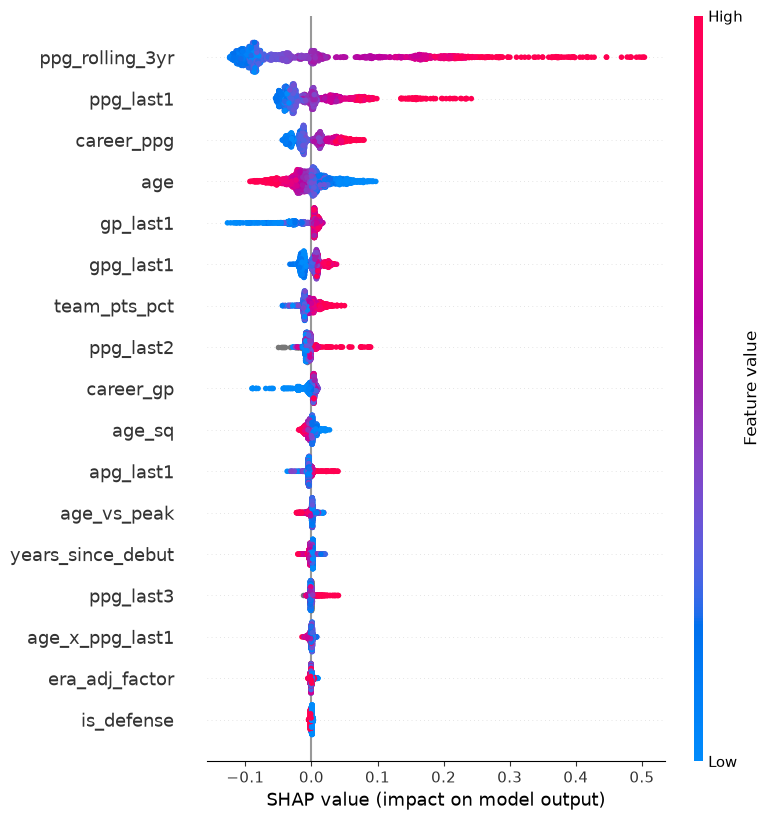

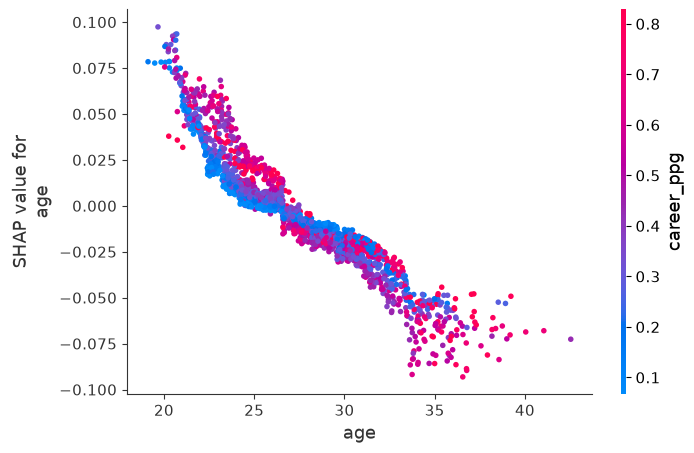

In [11]:
import shap
from src.features import VETERAN_FEATURES
from src.model import train_model
from src.constants import season_window, FIRST_BACKTEST_SEASON, LAST_BACKTEST_SEASON

final_window = season_window(FIRST_BACKTEST_SEASON, LAST_BACKTEST_SEASON)[-6:-1]
train = veterans[veterans['next_season_actual'].isin(final_window)]
trained = train_model(train, VETERAN_FEATURES, 'ppg_next', order_col='next_season_actual')

sample = train[VETERAN_FEATURES].sample(min(2000, len(train)), random_state=42)
explainer = shap.TreeExplainer(trained.model)
shap_values = explainer.shap_values(sample)
shap.summary_plot(shap_values, sample, show=False)
plt.show()
shap.dependence_plot('age', shap_values, sample, show=False)
plt.show()

## Findings

See `WRITEUP.md` for the full narrative.